<a href="https://colab.research.google.com/github/SultanKhassenov/gan-reviews/blob/main/01_explore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. Анализ датасета

Цель: понять состав собранных отзывов с Kaspi.

**Что проверяем:**
- Распределение по категориям
- Распределение длины (в словах и символах)
- Распределение рейтингов
- Распределение по языкам (русский / казахский / смешанный)
- Примеры отзывов из каждой категории


In [2]:
# === Colab setup (skip if running locally) ===
import os, sys

IN_COLAB = "COLAB_GPU" in os.environ
if IN_COLAB:
    # Клонируем репо (первый раз) и переходим в него
    if not os.path.exists("/content/gan-reviews"):
        !git clone https://github.com/SultanKhassenov/gan-reviews.git /content/gan-reviews
    %cd /content/gan-reviews
    !pip install -q -r requirements-trainer.txt

# Добавляем корень репо в sys.path, чтобы импорты работали из notebooks/
sys.path.insert(0, os.path.abspath(".."))

# Mount Google Drive для сохранения чекпоинтов (опционально)
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    CHECKPOINT_DIR = "/content/drive/MyDrive/gan-reviews/checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
else:
    CHECKPOINT_DIR = "../checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("CHECKPOINT_DIR =", CHECKPOINT_DIR)


/content/gan-reviews
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CHECKPOINT_DIR = /content/drive/MyDrive/gan-reviews/checkpoints


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = 'data/raw/reviews.jsonl'

rows = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in f:
        rows.append(json.loads(line))
df = pd.DataFrame(rows)
print(f'Всего отзывов: {len(df)}')
df.head()


Всего отзывов: 3588


,id,author,rating,text,date,url,category,product_title
0,ed34f4ee2f9e8cdd,Құртқа,5,"Спасибо большое, телефон оригинальный, все уст...",21.09.2025,https://kaspi.kz/shop/p/apple-iphone-17-pro-25...,smartphones,Смартфон Apple iPhone 17 Pro 256Gb NanoSIM&#43...
1,295b923bc284fc66,Санжар,1,"Телефон глючит, нормально не открывается. Лаги...",02.10.2025,https://kaspi.kz/shop/p/apple-iphone-17-pro-25...,smartphones,Смартфон Apple iPhone 17 Pro 256Gb NanoSIM&#43...
2,caa4182398807949,Сырымбет,1,"Американская сборка только Е сим, лагает Е сим.",07.10.2025,https://kaspi.kz/shop/p/apple-iphone-17-pro-25...,smartphones,Смартфон Apple iPhone 17 Pro 256Gb NanoSIM&#43...
3,01a3052cf6304985,Хайрулло,1,"Е сим проблемы, лучше не брать, 3 день еле уст...",25.11.2025,https://kaspi.kz/shop/p/apple-iphone-17-pro-25...,smartphones,Смартфон Apple iPhone 17 Pro 256Gb NanoSIM&#43...
4,7af440a211df9cd2,Владислав,5,"Переехал с 11-го. Небо и земля, камера крутая,...",27.09.2025,https://kaspi.kz/shop/p/apple-iphone-17-pro-25...,smartphones,Смартфон Apple iPhone 17 Pro 256Gb NanoSIM&#43...


In [5]:
!mkdir results


## Распределение по категориям


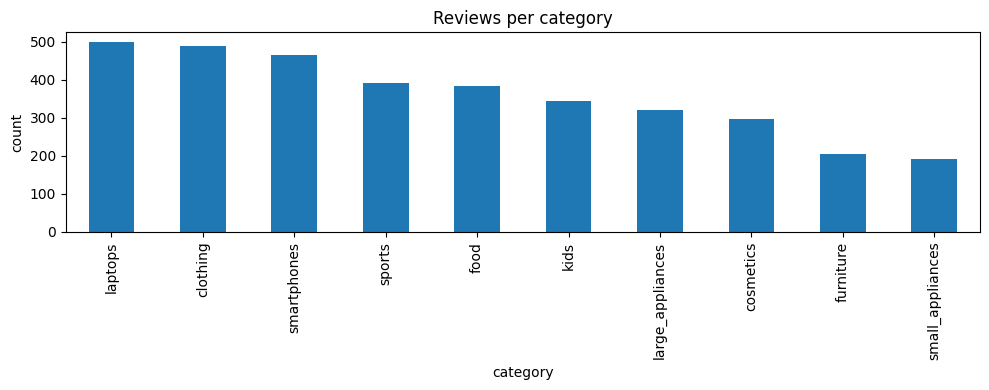

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
df['category'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Reviews per category')
ax.set_ylabel('count')
plt.tight_layout()
plt.savefig('results/eda_categories.png', dpi=120)
plt.show()


## Распределение длины


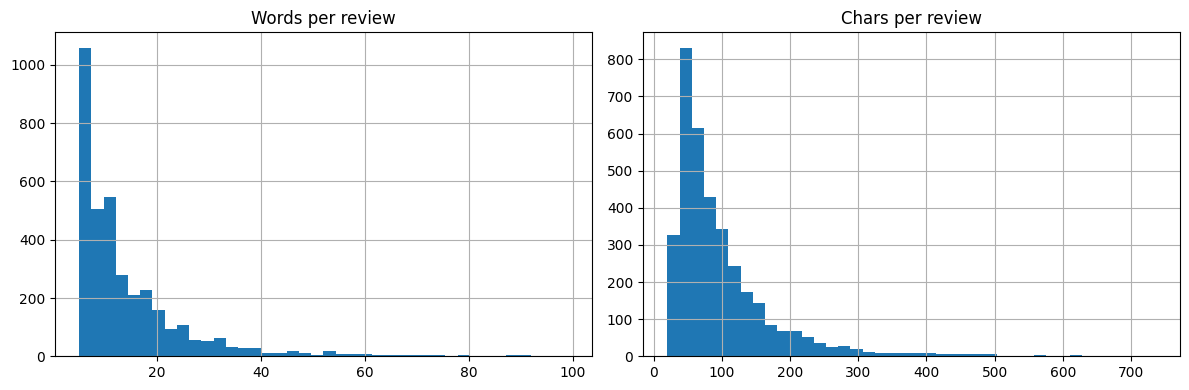

In [9]:
df['n_words'] = df['text'].str.split().str.len()
df['n_chars'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['n_words'].hist(bins=40, ax=axes[0])
axes[0].set_title('Words per review')
df['n_chars'].hist(bins=40, ax=axes[1])
axes[1].set_title('Chars per review')
plt.tight_layout()
plt.savefig('results/eda_lengths.png', dpi=120)
plt.show()


## Распределение рейтингов


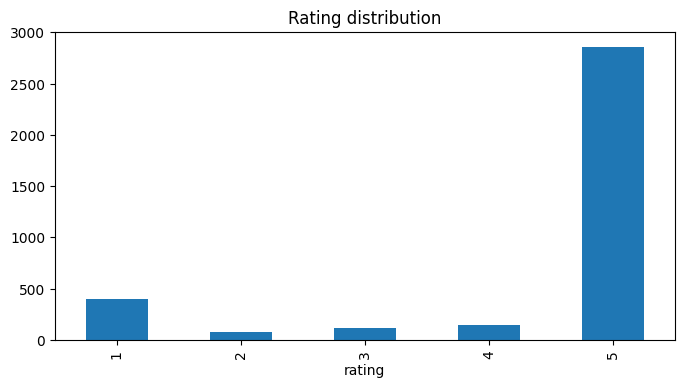

rating             1   2   3   4    5
category                             
clothing          96  15  26  34  319
cosmetics         47   5  12   8  224
food              61  20  17   7  278
furniture         63   9  17  13  102
kids              43   5   3  12  282
laptops           16   5   8  27  444
large_appliances  10   3   4  14  290
small_appliances   1   1   0   2  187
smartphones       28   2  11  13  412
sports            29  10  16  13  324


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Rating distribution')
plt.savefig('results/eda_ratings.png', dpi=120)
plt.show()

# Crosstab category x rating
ct = pd.crosstab(df['category'], df['rating'])
print(ct)


## Детекция языка

Простой подход: считаем долю символов казахского алфавита (ә, ө, ұ, ү, ң, қ, ғ, һ, і).
Точнее можно через `langdetect`, но эта эвристика быстра и достаточна.


In [11]:
KZ_LETTERS = set('әөұүңқғһі')

def kz_ratio(text):
    if not text: return 0.0
    cyrillic = [c for c in text.lower() if c.isalpha()]
    if not cyrillic: return 0.0
    return sum(c in KZ_LETTERS for c in cyrillic) / len(cyrillic)

df['kz_ratio'] = df['text'].apply(kz_ratio)
df['lang'] = df['kz_ratio'].apply(
    lambda r: 'kk' if r > 0.05 else ('ru' if r >= 0 else 'unk')
)
print(df['lang'].value_counts())


lang
ru    2763
kk     825
Name: count, dtype: int64


## Примеры отзывов по категориям


In [12]:
for cat in df['category'].unique():
    sub = df[df['category'] == cat].head(3)
    print(f'\n=== {cat} ===')
    for _, r in sub.iterrows():
        print(f"  [{r['rating']}*] {r['text'][:120]}")



=== smartphones ===
  [5*] Спасибо большое, телефон оригинальный, все устраивает.
  [1*] Телефон глючит, нормально не открывается. Лаги какие то. Не советую!
  [1*] Американская сборка только Е сим, лагает Е сим.

=== laptops ===
  [5*] Долго присматривать к Маку на процессоре М1, до этого только на винде были. Переход прошёл безболезненно, пару часов и к
  [1*] После ASUS, ничего непонятно. Греется также как и обычный ноутбук.
  [5*] 1. Невероятно быстрый, примерно как Айфон; 2. Бесшумный, так как нет вентилятора. Соответственно не придётся вскрывать и

=== small_appliances ===
  [5*] Мясорубка хорошая, со своей задачей справляется отлично Мясо перемалывает быстро, без застреваний. Пользоваться удобно, 
  [5*] Отличная мясорубка! Мощная, быстро справляется с мясом, не особо шумная. Удобна в использовании и легко собирается. Поку
  [5*] Керемет ұнады, сапасы жақсы екен.

=== clothing ===
  [5*] Идеально село по фигуре. Заказывала у ИП АБИШЕВА. Брала 48 размер девочки, вот мои параметр